## Import Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras._tf_keras.keras import layers
from keras._tf_keras.keras.models import Sequential
from keras._tf_keras.keras.layers import Dense,Flatten,Dropout,BatchNormalization
from keras._tf_keras.keras.losses import SparseCategoricalCrossentropy
from keras._tf_keras.keras.callbacks import EarlyStopping

## Set Constant Values

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 224
CHANNELS = 3

## Download or load the dataset 

In [3]:
training = "datasets/Malaria/train/"
testing = "datasets/Malaria/test/"

## Image Preprocessing

### Create Dataset for train,test,validation

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  training,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMAGE_SIZE, IMAGE_SIZE),
  batch_size=BATCH_SIZE)

Found 13152 files belonging to 2 classes.
Using 10522 files for training.


In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory(
  testing,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMAGE_SIZE, IMAGE_SIZE),
  batch_size=BATCH_SIZE)

Found 626 files belonging to 2 classes.
Using 501 files for training.


In [6]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  training,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(IMAGE_SIZE, IMAGE_SIZE),
  batch_size=BATCH_SIZE)

Found 13152 files belonging to 2 classes.
Using 2630 files for validation.


In [7]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

['Parasitized', 'Uninfected']


## Visualize the data

In [8]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 224, 224, 3)
(32,)


## Configure the dataset for performance

In [9]:
trian_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

## Standardize the data

In [10]:
normalization_layer = layers.Rescaling(1./255)

In [11]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.078431375 0.9568628


## Resize and Rescale

In [12]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(0.1 / 256)
])

## Data Augmentation

In [13]:
data_augmentation  = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2)
])

In [14]:
train_ds = train_ds.map(
    lambda x,y: (data_augmentation(x, training=True),y),
).prefetch(buffer_size = tf.data.AUTOTUNE)

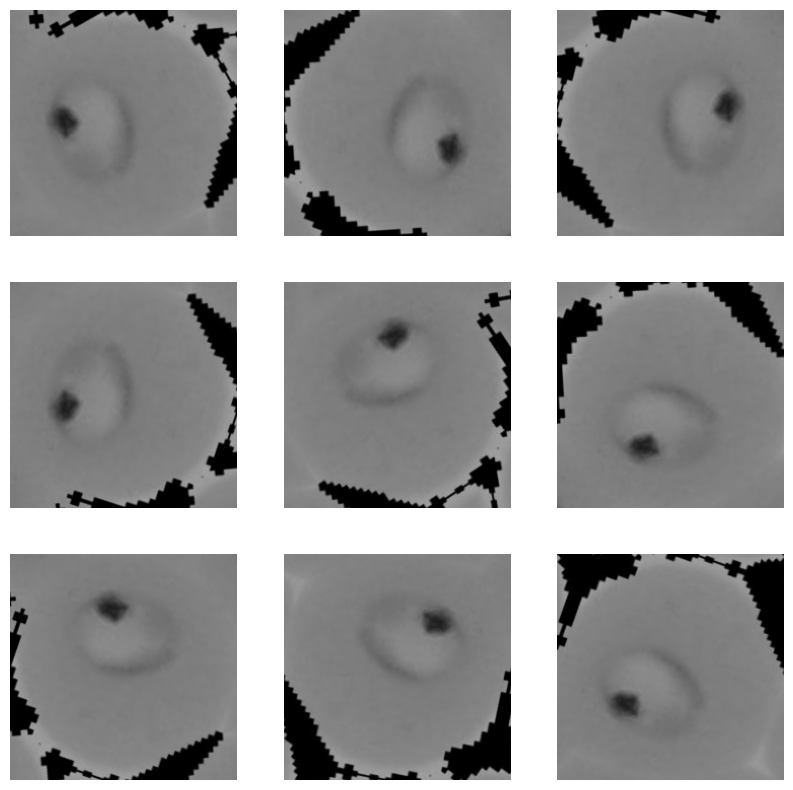

In [15]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

Define the EarlyStopping callback

In [16]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # or 'val_accuracy' depending on your goal
    patience=3,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True,  # Restore model weights from the epoch with the best value of the monitored quantity
    verbose=1
)

# DenseNet Model Implementation

In [17]:
from keras._tf_keras.keras.applications import DenseNet201
base_model = DenseNet201(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [18]:
model_dense = Sequential()
resize_and_rescale
model_dense.add(base_model)
model_dense.add(Flatten())
model_dense.add(Dense(256,activation='relu'))
model_dense.add(Dropout(0.5))
model_dense.add(BatchNormalization())
model_dense.add(Dense(num_classes,activation='sigmoid'))
model_dense.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 94080)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    24,084,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,408,258 (161.77 MB)

 Trainable params: 24,085,762 (91.88 MB)

 Non-trainable params: 18,322,496 (69.89 MB)

In [19]:
model_dense.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

Train the model

In [20]:
epochs = 10
history = model_dense.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=early_stopping
)

Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1613s 5s/step - accuracy: 0.5900 - loss: 0.7748 - val_accuracy: 0.5764 - val_loss: 0.6642
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1607s 5s/step - accuracy: 0.7024 - loss: 0.5748 - val_accuracy: 0.6616 - val_loss: 0.6088
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1622s 5s/step - accuracy: 0.6733 - loss: 0.6004 - val_accuracy: 0.7240 - val_loss: 0.5835
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1622s 5s/step - accuracy: 0.6751 - loss: 0.5937 - val_accuracy: 0.5110 - val_loss: 1.0407
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1607s 5s/step - accuracy: 0.6785 - loss: 0.5838 - val_accuracy: 0.7224 - val_loss: 0.5729
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1608s 5s/step - accuracy: 0.6831 - loss: 0.5713 - val_accuracy: 0.7711 - val_loss: 0.4997
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1607s 5s/step - accuracy: 0.7044 - loss: 0.5695 - val_accuracy: 0.7198 - val_loss: 0.5475
Epoch 8/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 1607s 5s/step - accuracy: 0.7036 - loss: 0.5510 - 

Evaluate the model

In [21]:
model_dense.evaluate(test_ds)

16/16 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - accuracy: 0.8014 - loss: 0.4245


[0.44637957215309143, 0.7944111824035645]

Visualize training accuracy and loss

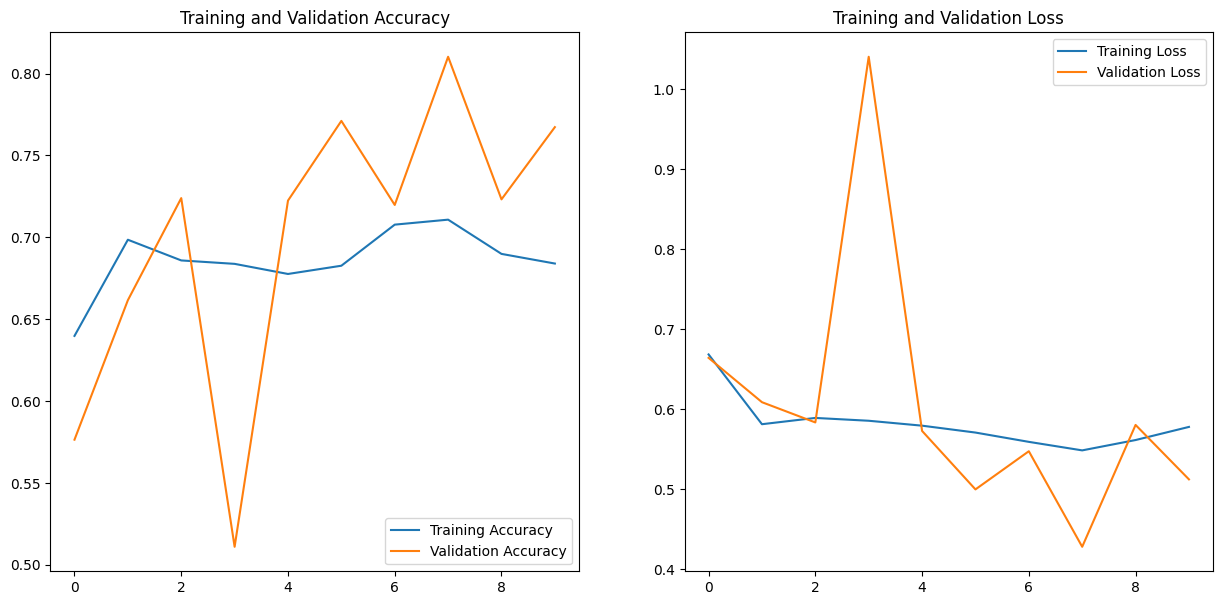

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']

val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Save the model

In [23]:
model_dense.save('Model DenseNet.keras')

# MobileNet Model Implementation

In [24]:
from keras._tf_keras.keras.applications import MobileNet
base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [25]:
model_mobile = Sequential()
resize_and_rescale
model_mobile.add(base_model)
model_mobile.add(Flatten())
model_mobile.add(Dense(256,activation='relu'))
model_mobile.add(Dropout(0.5))
model_mobile.add(BatchNormalization())
model_mobile.add(Dense(num_classes,activation='sigmoid'))
model_mobile.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,075,714 (61.32 MB)

 Trainable params: 12,846,338 (49.00 MB)

 Non-trainable params: 3,229,376 (12.32 MB)

In [26]:
model_mobile.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

Train the model

In [27]:
epochs = 10
history = model_mobile.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=early_stopping
)

Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 284s 852ms/step - accuracy: 0.6342 - loss: 0.7050 - val_accuracy: 0.7540 - val_loss: 0.5039
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 284s 862ms/step - accuracy: 0.7437 - loss: 0.5155 - val_accuracy: 0.7798 - val_loss: 0.4487
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 282s 856ms/step - accuracy: 0.7311 - loss: 0.5235 - val_accuracy: 0.7753 - val_loss: 0.4623
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


Evaluate the model

In [28]:
model_mobile.evaluate(test_ds)

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 576ms/step - accuracy: 0.7335 - loss: 0.5308


[0.5301772356033325, 0.7405189871788025]

Visualize training accuracy and losses

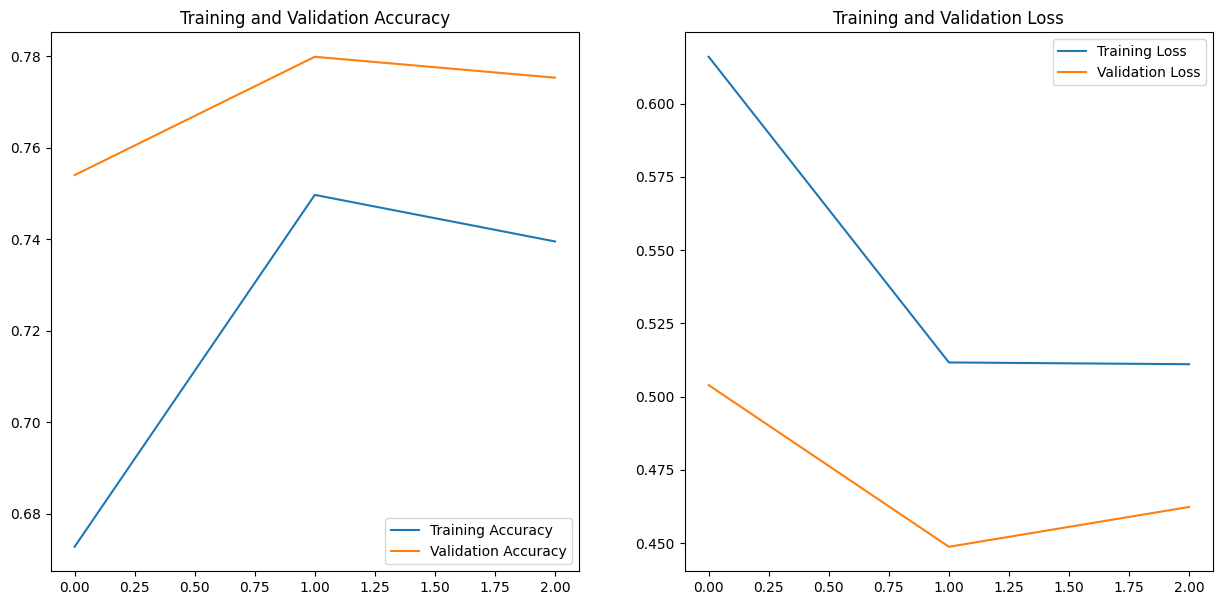

In [30]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']

val_loss = history.history['val_loss']

epochs_range = range(3)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Save the model

In [31]:
model_mobile.save('Model MobileNet.keras')

# EfficientNet Model Implemantation

Import Base Model

In [36]:
from keras._tf_keras.keras.applications.efficientnet_v2 import EfficientNetV2B0
base_model = EfficientNetV2B0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

Add connected layers to base model

In [37]:
model_eff = Sequential()
resize_and_rescale
model_eff.add(base_model)
model_eff.add(Flatten())
model_eff.add(Dense(256,activation='relu'))
model_eff.add(Dropout(0.5))
model_eff.add(BatchNormalization())
model_eff.add(Dense(num_classes,activation='sigmoid'))
model_eff.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    16,056,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,977,426 (83.84 MB)

 Trainable params: 16,057,602 (61.25 MB)

 Non-trainable params: 5,919,824 (22.58 MB)

Compile the model

In [38]:
model_eff.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

Train the model

In [39]:
epochs = 10
history = model_eff.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=early_stopping
)

Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.7847 - loss: 0.5188 - val_accuracy: 0.9114 - val_loss: 0.2258
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.8681 - loss: 0.3156 - val_accuracy: 0.9190 - val_loss: 0.1952
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 358s 1s/step - accuracy: 0.8772 - loss: 0.2890 - val_accuracy: 0.9190 - val_loss: 0.1980
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 352s 1s/step - accuracy: 0.8811 - loss: 0.2759 - val_accuracy: 0.9293 - val_loss: 0.1818
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 351s 1s/step - accuracy: 0.8914 - loss: 0.2717 - val_accuracy: 0.9319 - val_loss: 0.1792
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 352s 1s/step - accuracy: 0.8959 - loss: 0.2603 - val_accuracy: 0.9285 - val_loss: 0.1829
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy: 0.8873 - loss: 0.2673 - val_accuracy: 0.9312 - val_loss: 0.1771
Epoch 8/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 351s 1s/step - accuracy: 0.8968 - loss: 0.2582 - val_accu

Evaluate the Model

In [ ]:
model_eff.evaluate(test_ds)S

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 678ms/step - accuracy: 0.9002 - loss: 0.2272


[0.21331416070461273, 0.9021956324577332]

# Visualize training accuracy and losses

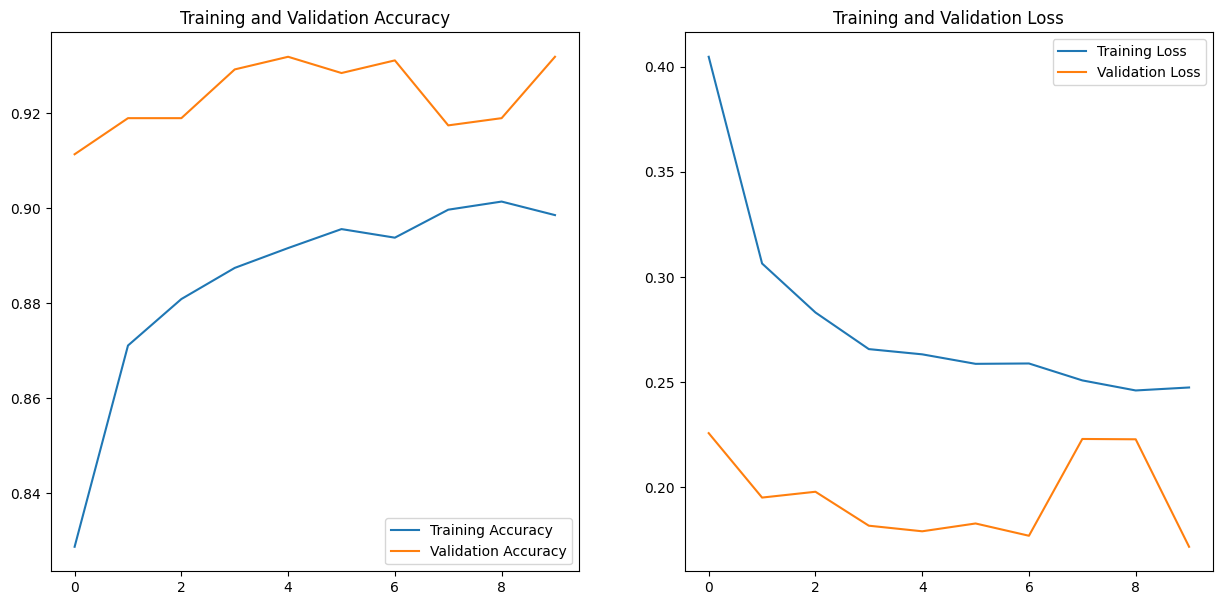

In [41]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']

val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Save the Model

In [42]:
model_eff.save('Model EfficientNet.keras')